**Goal:** build a Perceptron from scratch -- the original mistake-driven linear classifier --
watch it converge to a separating line, then watch it fail to converge when the classes
overlap. Pairs with the concept note
[Linear Models for Classification](l05_concept_linear_classification.qmd).

> **Previously:** L04 -- Logistic Regression  |  **Next:** L06 -- Gaussian Discriminant Analysis

> This page is the read-only view. To run the lab, open the notebook
> (`l05_lab_linear_classification.ipynb`) -- in Colab via the badge on the concept page,
> or locally.

## Scenario

A cooperative sorts coffee beans into two grades from two cheap measurements per bean -- a
size index and a density index. When the two grades are physically distinct the measurements
separate them cleanly; when the grades shade into each other, they overlap. We will train a
Perceptron on both cases and see the difference the algorithm cares about most: whether a
single straight line can separate the classes.

The data below is **synthetic** (fixed seed, identical for everyone) with fictionalized but
plausible values.

## Setup

The setup is **two cells** (the pattern every lab in the course uses). The first only installs;
the second imports, seeds the generator, and builds the data -- so re-running imports never
re-installs.

In [1]:
# Setup, cell 1 of 2 -- INSTALL (run once; Colab wipes installs when it resets on open)
# Colab already ships scikit-learn, numpy and matplotlib, so this is effectively a no-op there.
%pip install -q scikit-learn
# local, in a terminal (not in the notebook):  uv add scikit-learn numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Setup, cell 2 of 2 -- IMPORTS, SEED, DATA (safe to re-run without re-installing)
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(7)           # fixed seed: identical data for everyone
n = 50                                   # beans per grade

grade_A = rng.normal([2.0, 2.0], 0.5, (n, 2))   # class 0: well separated from B
grade_B = rng.normal([3.4, 3.4], 0.5, (n, 2))   # class 1
X = np.vstack([grade_A, grade_B])
y = np.array([0] * n + [1] * n)
print("samples:", X.shape[0], "features:", X.shape[1], "classes:", sorted(set(y.tolist())))

samples: 100 features: 2 classes: [0, 1]


~~~text
samples: 100 features: 2 classes: [0, 1]
~~~

## Step 1: A Perceptron by Hand, Then in a Loop

### Naive approach: one update, by hand

The Perceptron starts with all weights and bias at zero, so its first prediction for *every*
point is `step(0) = 1`. Take the very first bean (a grade-A point, true label 0): the model
says 1, which is wrong, so the rule nudges the line. Apply it once, by hand:

In [3]:
w = np.zeros(2)
b = 0.0
x0, y0 = X[0], y[0]
yhat0 = int(x0 @ w + b >= 0.0)
print(f"point x0 = {np.round(x0, 3).tolist()}, true = {y0}, predicted = {yhat0}")

lr = 0.1
delta = lr * (y0 - yhat0)                 # (y - yhat): +1, 0, or -1, scaled by the learning rate
w = w + delta * x0
b = b + delta
print(f"delta = {delta}")
print(f"after one update: w = {np.round(w, 3).tolist()}, b = {round(b, 3)}")

point x0 = [2.001, 2.149], true = 0, predicted = 1
delta = -0.1
after one update: w = [-0.2, -0.215], b = -0.1


~~~text
point x0 = [2.001, 2.149], true = 0, predicted = 1
delta = -0.1
after one update: w = [-0.2, -0.215], b = -0.1
~~~

One mistake, one nudge: the weights moved *away* from this point (delta is negative because the
model over-predicted), so next time the boundary leans toward calling it grade A. That is the
whole learning rule -- we just need to repeat it over every point, for as many passes as it takes.

### Better approach: the full training loop

In [4]:
def train_perceptron(X, y, lr=0.1, epochs=20, shuffle_seed=0):
    w = np.zeros(X.shape[1])
    b = 0.0
    order_rng = np.random.default_rng(shuffle_seed)
    errors_per_epoch = []
    for ep in range(epochs):
        for i in order_rng.permutation(len(y)):       # visit points in a (seeded) shuffled order
            yhat = int(X[i] @ w + b >= 0.0)
            delta = lr * (y[i] - yhat)
            if delta != 0.0:                          # update ONLY on a mistake
                w = w + delta * X[i]
                b = b + delta
        errors = int((((X @ w + b) >= 0).astype(int) != y).sum())   # errors with the current line
        errors_per_epoch.append(errors)
        if errors == 0:                               # separable -> we can stop
            break
    return w, b, errors_per_epoch

w, b, curve = train_perceptron(X, y)
acc = (((X @ w + b) >= 0).astype(int) == y).mean()
print("errors per epoch:", curve)
print(f"converged in {len(curve)} epochs, training accuracy = {acc:.3f}")
print(f"weights = {np.round(w, 3).tolist()}, bias = {round(b, 3)}")

errors per epoch: [43, 22, 5, 0]
converged in 4 epochs, training accuracy = 1.000
weights = [0.41, 0.371], bias = -2.0


~~~text
errors per epoch: [43, 22, 5, 0]
converged in 4 epochs, training accuracy = 1.000
weights = [0.41, 0.371], bias = -2.0
~~~

The mistake count falls 43, 22, 5, 0: each pass fixes more points until a pass makes no errors
at all, and the loop stops. That is the convergence theorem in action -- the data is linearly
separable, so the Perceptron is *guaranteed* to find a perfect line, and it did. Draw it:

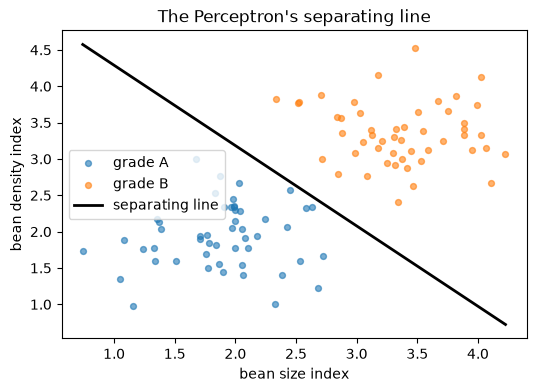

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
for cls in (0, 1):
    pts = X[y == cls]
    ax.scatter(pts[:, 0], pts[:, 1], label=f"grade {'AB'[cls]}", alpha=0.6, s=18)
xs = np.linspace(X[:, 0].min(), X[:, 0].max(), 50)
ax.plot(xs, -(w[0] * xs + b) / w[1], "k-", linewidth=2, label="separating line")
ax.set_xlabel("bean size index")
ax.set_ylabel("bean density index")
ax.legend()
ax.set_title("The Perceptron's separating line")
plt.show()

The black line is the separating hyperplane `w . x + b = 0`: every grade-A bean on one side,
every grade-B bean on the other.

## Step 2: The Same Job in scikit-learn -- completion problem

You will rarely hand-roll a Perceptron -- scikit-learn ships one with the same `fit` / `score`
interface as every other model. Complete the marked lines:

In [6]:
from sklearn.linear_model import Perceptron

# Uncomment and complete the marked lines:
# clf = Perceptron(random_state=7).fit(____, ____)       # fit on X and y
# print(f"sklearn accuracy = {clf.score(X, y):.3f}")
# print(f"coef = {np.round(clf.coef_[0], 3).tolist()}, intercept = {round(float(clf.intercept_[0]), 3)}")

<details><summary>Expected Output</summary>

~~~text
sklearn accuracy = 1.000
coef = [3.7, 2.693], intercept = -17.0
~~~

Also 100% accurate -- but look at the weights: `[3.7, 2.693]` with intercept `-17.0`, nothing
like our scratch model's `[0.41, 0.371]` with bias `-2.0`. **Both lines separate the data
perfectly; they are just different lines.** The Perceptron finds *a* separator, not a unique
one -- which is exactly the gap the support vector machine (L08) closes by choosing the single
widest-margin line.
</details>

## Your Turn

### Exercise 1 -- When no line can separate them

Rebuild the two grades with a much larger spread so the classes **overlap**, then train the
same `train_perceptron` on them. Watch the error count: does it ever reach zero? Compare its
accuracy with logistic regression on the identical data.

**Hint:** reuse the Step-1 generator with `np.random.default_rng(7)` but spread `1.1` instead of `0.5`; call `train_perceptron(Xo, yo, epochs=15)`; then fit `sklearn.linear_model.LogisticRegression` on the same `Xo, yo`.

In [7]:
# TODO: your code here

<details><summary>Expected Output</summary>

~~~text
errors per epoch: [40, 19, 33, 12, 26, 30, 14, 27, 26, 19, 40, 50, 13, 23, 23]
perceptron accuracy = 0.770
logistic accuracy = 0.890
~~~

The mistake count never reaches zero -- it just bounces around (12 one pass, 50 the next),
because no single line can split overlapping classes, so there is always a point demanding a
nudge. The Perceptron never settles, and where you stop it is arbitrary (0.770 here, but it
would differ if you ran one more epoch). Logistic regression, built on a smooth loss instead of
mistake-chasing, lands on a stable, better boundary (0.890). This is *why* the later linear
classifiers exist.
</details>

### Exercise 2 -- A different line, equally perfect

Go back to the separable data and train the scratch Perceptron again, but change the order it
visits the points. Does it find the same line? Does it still separate the data?

**Hint:** call `train_perceptron(X, y, shuffle_seed=2)` and compare its weights and bias with the first run's `[0.41, 0.371]`, `-2.0`.

In [8]:
# TODO: your code here

<details><summary>Expected Output</summary>

~~~text
shuffle_seed=2: converged in 2 epochs, accuracy = 1.000
new line:  weights = [0.258, 0.209], bias = -1.2
first run: weights = [0.41, 0.371], bias = -2.0
~~~

Same data, a different visiting order, a **different** separating line -- and it is still 100%
accurate. The Perceptron has no preference among the many lines that separate the classes; it
keeps whichever one its corrections happen to land on. When the *specific* boundary matters
(robustness to new points), you want the max-margin choice -- the support vector machine, L08.
</details>

## Summary

- A linear classifier is a **separating hyperplane** `w . x + b = 0`; the sign of the score is
  the predicted class.
- The Perceptron learns by **correcting its mistakes** -- `w += eta (y - yhat) x` -- and on
  linearly separable data it is guaranteed to converge to zero errors (here, in 4 epochs).
- When the classes **overlap**, no line separates them, so the Perceptron never converges: its
  error count just oscillates. Logistic regression (smooth loss) handles overlap; the SVM (L08)
  picks the single best-margin line.
- It finds *a* separator, not a unique one -- a different point order gives a different perfect
  line.
- Next (L06): a different way to classify entirely -- **generative** models that learn what each
  class *looks like* and apply Bayes' rule, starting with Gaussian discriminant analysis.